In [30]:
import anndata
import scanpy as sc
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.colors import ListedColormap
import scipy 
import sklearn.metrics
import seaborn as sns
import scipy.sparse as sp
import os

sns.set_palette("colorblind")
plt.rc('xtick', labelsize=11)
plt.rc('ytick', labelsize=11)
plt.rcParams.update({'font.size': 11})

In [31]:
from platform import python_version
print(f'Python version: {python_version()}')
print(f'Scanpy version: {sc.__version__}')

Python version: 3.9.25
Scanpy version: 1.10.3


In [32]:
data_path = 'data/'

# Original Data Analysis Pipeline

## Data Loading

In [4]:
# load raw protein dataset

filename = '20210919_DIANN_SingleCellOutput.pg_matrix_notnormalized.tsv'

cols = list(pd.read_csv(data_path + filename, nrows=1, sep='\t'))
prot = pd.read_csv(data_path + filename, usecols =[i for i in cols if 'TSCP_DIA_SingleCell' in i], sep='\t')
var_annotation = pd.read_csv(data_path + filename, index_col = 'Genes', usecols = ['Genes'], sep='\t')
prot = prot.fillna(0.)
prot[prot == 'Filtered'] = 0.

adata_prot_raw = anndata.AnnData(prot.transpose())
adata_prot_raw.var = var_annotation
adata_prot_raw.var_names = adata_prot_raw.var_names.map(str)
adata_prot_raw.var_names_make_unique()

C:\Users\shiy\miniconda3\envs\Scanpy\lib\site-packages\anndata\_core\aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


In [5]:
# load protein dataset with local regression normalization

filename = '20210919_DIANN_SingleCellOutput.pg_matrix_cellcyclepred.tsv'

cols = list(pd.read_csv(data_path + filename, nrows=1, sep='\t'))
prot = pd.read_csv(data_path + filename, usecols =[i for i in cols if 'TSCP_DIA_SingleCell' in i], sep='\t')
var_annotation = pd.read_csv(data_path + filename, index_col = 'Genes', usecols = ['Genes'], sep='\t')
prot[prot == 'Filtered'] = np.nan

adata_prot = anndata.AnnData(prot.transpose())
adata_prot.var = var_annotation
adata_prot.var_names = adata_prot.var_names.map(str)
adata_prot.var_names_make_unique()

protein_adata = adata_prot

C:\Users\shiy\miniconda3\envs\Scanpy\lib\site-packages\anndata\_core\aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


## Cell Cycle Analysis

### Fig. 4C - Total protein signal per cell grouped by cell cycle stage

In [44]:
adata_raw = adata_prot_raw.copy()
sc.pp.filter_cells(adata_raw, min_genes=600)
sc.pp.filter_genes(adata_raw, min_cells=0.15 * adata_raw.shape[0])

adata_raw.obs['cell cycle stage'] = [
    'G1' if '_G1_' in name
    else 'G1-S' if '_TB_' in name
    else 'G2' if '_G2_' in name
    else 'G2-M' if '_NB_' in name
    else 'other'
    for name in adata_raw.obs_names
]

C:\Users\shiy\AppData\Local\Temp\ipykernel_68420\2456188054.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=x, y=y, palette="colorblind")


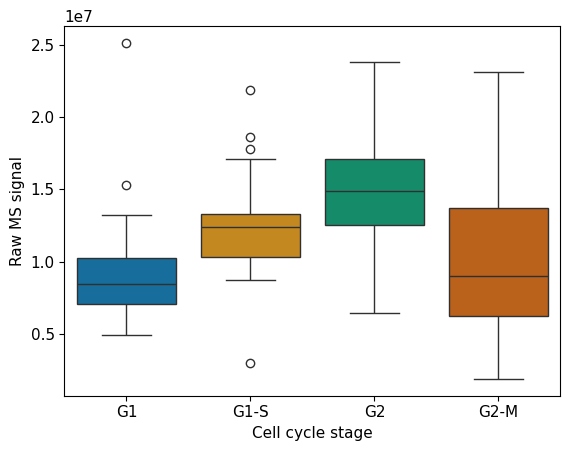

In [45]:
size = {cond: adata_raw[adata_raw.obs['cell cycle stage'] == cond].X.sum(axis=1)
       for cond in ['G1', 'G1-S', 'G2', 'G2-M']}
x = np.concatenate([[cond] * len(cells) for cond, cells in size.items()])
y = np.concatenate([cells for cells in size.values()])
sns.boxplot(x=x, y=y, palette="colorblind")
plt.xlabel("Cell cycle stage")
plt.ylabel("Raw MS signal")
plt.show()

In [46]:
for cond, d in size.items():
    print(f'{cond}:\t n = {len(d)},\t median = {np.median(d)}')

G1:	 n = 84,	 median = 8477523.6485
G1-S:	 n = 41,	 median = 12429286.908
G2:	 n = 52,	 median = 14910478.361000001
G2-M:	 n = 45,	 median = 9016381.392


### Fig. 4D - Principal Component Analysis

In [47]:
def impute_downshifted_normal_global(
        adata,
        scale=0.3,
        shift=1.8,
):
    np.random.seed(42)
    mean = np.nanmean(adata.X)
    std = np.nanstd(adata.X)
    draws = np.random.normal(loc=mean - shift * std, scale=scale * std, size=np.sum(np.isnan(adata.X)))
    adata.X[np.isnan(adata.X)] = draws

In [48]:
adata = protein_adata.copy()
sc.pp.filter_cells(adata, min_genes=600)
sc.pp.filter_genes(adata, min_cells=0.15 * adata.shape[0])
sc.pp.log1p(adata)
impute_downshifted_normal_global(adata)

adata.obs['cell cycle stage'] = [
    'G1' if '_G1_' in name
    else 'G1-S' if '_TB_' in name
    else 'G2' if '_G2_' in name
    else 'G2-M' if '_NB_' in name
    else 'other'
    for name in adata.obs_names
]
adata = adata[adata.obs['cell cycle stage'] != 'other']

C:\Users\shiy\miniconda3\envs\Scanpy\lib\site-packages\scanpy\preprocessing\_pca.py:317: ImplicitModificationWarning: Setting element `.obsm['X_pca']` of view, initializing view as actual.
  adata.obsm[key_obsm] = X_pca


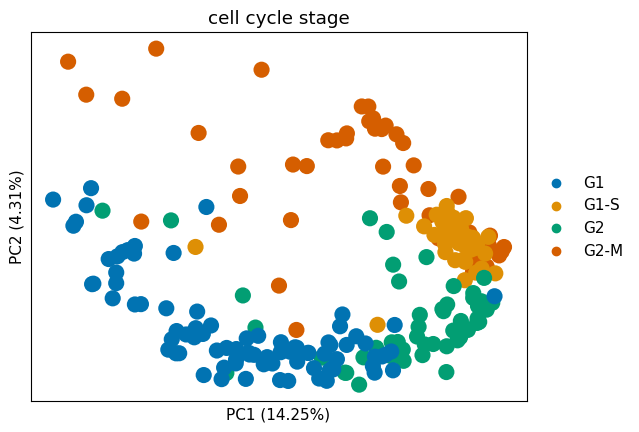

In [49]:
sc.pp.pca(adata)
sc.pl.pca(adata, color='cell cycle stage', annotate_var_explained=True)
plt.show()

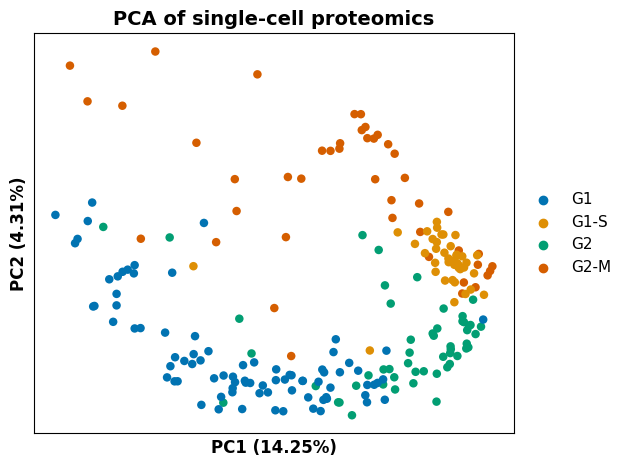

In [64]:
import scanpy as sc
import matplotlib.pyplot as plt

sc.pp.pca(adata)

sc.pl.pca(
    adata,
    color="cell cycle stage",
    annotate_var_explained=True,
    size=150,
    show=False
)

ax = plt.gca()

ax.set_title("PCA of single-cell proteomics", fontsize=14, fontweight="bold")
ax.set_xlabel(ax.get_xlabel(), fontsize=12, fontweight="bold")
ax.set_ylabel(ax.get_ylabel(), fontsize=12, fontweight="bold")

ax.grid(True, linestyle="--", linewidth=1.5)

plt.tight_layout()

plt.savefig("PCA_cell_cycle.png", dpi=600, bbox_inches="tight")
plt.savefig("PCA_cell_cycle.pdf", dpi=300, bbox_inches="tight")

plt.show()

### Fig. 4E - Cell cycle stage prediction 

In [69]:
# Export filtered data for SoftHybrid Imputation
adata = protein_adata.copy()
sc.pp.filter_cells(adata, min_genes=600)
sc.pp.filter_genes(adata, min_cells=0.15 * adata.shape[0])

X = adata.X
if sp.issparse(X):
    X = X.toarray()

df = pd.DataFrame(
    X,
    index=adata.obs_names,
    columns=adata.var_names
)

os.makedirs("data", exist_ok=True)
df.to_csv("data/adata_filtered_for_R_15.tsv", sep="\t")

In [70]:
# Export filtered data for SoftHybrid Imputation
adata = protein_adata.copy()
sc.pp.filter_cells(adata, min_genes=600)
sc.pp.filter_genes(adata, min_cells=0.7 * adata.shape[0])

X = adata.X
if sp.issparse(X):
    X = X.toarray()

df = pd.DataFrame(
    X,
    index=adata.obs_names,
    columns=adata.var_names
)

os.makedirs("data", exist_ok=True)
df.to_csv("data/adata_filtered_both_for_R.tsv", sep="\t")

In [71]:
adata = protein_adata.copy()
sc.pp.filter_cells(adata, min_genes=600)
sc.pp.filter_genes(adata, min_cells=0.7 * adata.shape[0])
sc.pp.log1p(adata)
adata.X = np.nan_to_num(adata.X)

adata.obs['cell cycle stage'] = [
    'G1' if '_G1_' in name
    else 'G1-S' if '_TB_' in name
    else 'G2' if '_G2_' in name
    else 'G2-M' if '_NB_' in name
    else 'other'
    for name in adata.obs_names
]
adata = adata[adata.obs['cell cycle stage'] != 'other']

In [72]:
cc_markers = pd.read_excel("CellCycleMarker.xlsx", "Tami_Geiger")

g1_list = cc_markers['G1'][1:-1]
g1_list = [g for g in g1_list if g in adata.var_names]
print(f'G1:\t {", ".join(g1_list)}')

s_list = cc_markers['S'][1:-1]
s_list = [g for g in s_list if g in adata.var_names]
print(f'S:\t {", ".join(s_list)}')

g2m_list = cc_markers['G2M'][1:-1]
g2m_list = [g for g in g2m_list if g in adata.var_names]
print(f'G2M:\t {", ".join(g2m_list)}')

G1:	 MARCKS, KRT1, HIST1H1E, KRT18, HNRNPA1, CHCHD3, CD44, NASP, TARDBP, PODXL, SUMO2, STMN1, TRIM28, SPTAN1
S:	 NOLC1, ATP2A2, CANX, TMX1, CKB, SLC25A3, SLC16A1, MT-CO2, SRPRB, CYB5R3, LETM1, ANP32B
G2M:	 TOP2A, HMGB1, EIF5B, TMSB10, EIF3D, ANP32A, RCC2, FASN, LUC7L2, AARS, KPNA2, CKAP5


In [73]:
sc.tl.score_genes(adata, g1_list, score_name='g1')
sc.tl.score_genes(adata, s_list, score_name='s')
sc.tl.score_genes(adata, g2m_list, score_name='g2m')

C:\Users\shiy\miniconda3\envs\Scanpy\lib\site-packages\scanpy\tools\_score_genes.py:169: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs[score_name] = pd.Series(


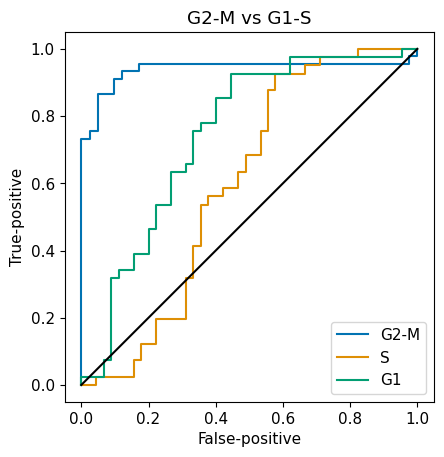

In [74]:
protein_data_nb_tb = adata[np.array(adata.obs['cell cycle stage'] == 'G2-M') 
                                  | np.array(adata.obs['cell cycle stage'] == 'G1-S')]

score = {
    'G2-M': protein_data_nb_tb.obs['g2m'].values,
    'S': protein_data_nb_tb.obs['s'].values,
    'G1': protein_data_nb_tb.obs['g1'].values
}

for phase in score.keys():
    true_label = np.array([phase in a for a in protein_data_nb_tb.obs['cell cycle stage'].values])
    scores = score[phase]
    fp, tp, _ = sklearn.metrics.roc_curve(true_label, scores)
    plt.plot(fp, tp, label=phase)
plt.plot([0, 1], [0, 1], c='black')
plt.gca().set_aspect('equal')
plt.xlabel('False-positive')
plt.ylabel('True-positive')
plt.legend()
plt.title('G2-M vs G1-S')
plt.show()

In [75]:
for phase in score.keys():
    true_label = np.array([phase in a for a in protein_data_nb_tb.obs['cell cycle stage'].values])
    scores = score[phase]
    print(f'AUC using the {phase} score: {sklearn.metrics.roc_auc_score(true_label, scores):.2f}')

AUC using the G2-M score: 0.94
AUC using the S score: 0.60
AUC using the G1 score: 0.74


### Cell cycle stage prediction

In [76]:
adata = protein_adata.copy()
sc.pp.filter_cells(adata, min_genes=600)
sc.pp.filter_genes(adata, min_cells=0.7 * adata.shape[0])
sc.pp.log1p(adata)
adata.X = np.nan_to_num(adata.X)

adata.obs['cell cycle stage'] = [
    'G1' if '_G1_' in name
    else 'G1-S' if '_TB_' in name
    else 'G2' if '_G2_' in name
    else 'G2-M' if '_NB_' in name
    else 'other'
    for name in adata.obs_names
]
adata = adata[adata.obs['cell cycle stage'] != 'other']

In [77]:
cc_markers = pd.read_excel("CellCycleMarker.xlsx", "Tami_Geiger")

g1_list = cc_markers['G1'][1:-1]
g1_list = [g for g in g1_list if g in adata.var_names]
print(f'G1:\t {", ".join(g1_list)}')

s_list = cc_markers['S'][1:-1]
s_list = [g for g in s_list if g in adata.var_names]
print(f'S:\t {", ".join(s_list)}')

g2m_list = cc_markers['G2M'][1:-1]
g2m_list = [g for g in g2m_list if g in adata.var_names]
print(f'G2M:\t {", ".join(g2m_list)}')

G1:	 MARCKS, KRT1, HIST1H1E, KRT18, HNRNPA1, CHCHD3, CD44, NASP, TARDBP, PODXL, SUMO2, STMN1, TRIM28, SPTAN1
S:	 NOLC1, ATP2A2, CANX, TMX1, CKB, SLC25A3, SLC16A1, MT-CO2, SRPRB, CYB5R3, LETM1, ANP32B
G2M:	 TOP2A, HMGB1, EIF5B, TMSB10, EIF3D, ANP32A, RCC2, FASN, LUC7L2, AARS, KPNA2, CKAP5


In [78]:
sc.tl.score_genes(adata, g1_list, score_name='g1')
sc.tl.score_genes(adata, s_list, score_name='s')
sc.tl.score_genes(adata, g2m_list, score_name='g2m')

C:\Users\shiy\miniconda3\envs\Scanpy\lib\site-packages\scanpy\tools\_score_genes.py:169: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs[score_name] = pd.Series(


AUC using the G2-M score: 0.46
AUC using the S score: 0.35
AUC using the G1 score: 0.67


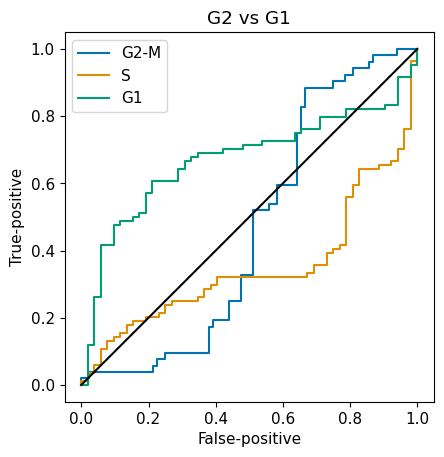

AUC using the G2-M score: 0.66
AUC using the S score: 0.52
AUC using the G1 score: 0.84


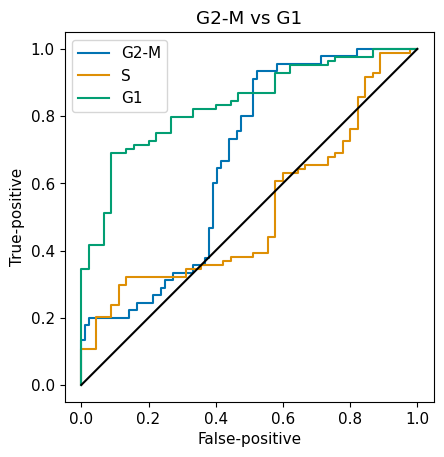

In [79]:
for pair in [('G2', 'G1'), ('G2-M', 'G1')]:
    data_comparison = adata[np.array(adata.obs['cell cycle stage'] == pair[0]) 
                                      | np.array(adata.obs['cell cycle stage'] == pair[1])]

    score = {}
    score['G2-M'] = data_comparison.obs['g2m'].values
    score['S'] = data_comparison.obs['s'].values
    score['G1'] = data_comparison.obs['g1'].values
    
    for phase in score.keys():
        true_label = np.array([phase in a or (phase == 'S' and a == 'G1') or a in phase for a in data_comparison.obs['cell cycle stage'].values])
        scores = score[phase]
        print(f'AUC using the {phase} score: {sklearn.metrics.roc_auc_score(true_label, scores):.2f}')
        fp, tp, _ = sklearn.metrics.roc_curve(true_label, scores)
        plt.plot(fp, tp, label=phase)
    plt.plot([0, 1], [0, 1], c='black')
    plt.gca().set_aspect('equal')
    plt.xlabel('False-positive')
    plt.ylabel('True-positive')
    plt.legend()
    plt.title(f'{pair[0]} vs {pair[1]}')
    plt.show()

# SoftHybrid Data Analysis Pipeline

In [45]:
# Load SoftHybrid Imputed Data
df_soft = pd.read_csv("SoftHybridImputation_best_both.tsv", sep="\t", index_col=0)

adata_soft = adata_prot_raw.copy()

# df_soft: rows = proteins, cols = samples
common_cells = [c for c in adata_soft.obs_names if c in df_soft.columns]
common_genes = [g for g in adata_soft.var_names if g in df_soft.index]

adata_soft = adata_soft[common_cells, common_genes].copy()
df_soft = df_soft.loc[common_genes, common_cells]

assert list(df_soft.index) == list(adata_soft.var_names)
assert list(df_soft.columns) == list(adata_soft.obs_names)

adata_soft.X = df_soft.T.values

In [47]:
def run_original_roc_code(adata, g1_list, s_list, g2m_list, plot=True):

    adata = assign_stage(adata)
    
    sc.tl.score_genes(adata, g1_list, score_name='g1')
    sc.tl.score_genes(adata, s_list, score_name='s')
    sc.tl.score_genes(adata, g2m_list, score_name='g2m')

    results = []

    # =========================
    # 1) G2-M vs G1-S
    # =========================
    protein_data_nb_tb = adata[
        np.array(adata.obs['cell cycle stage'] == 'G2-M') |
        np.array(adata.obs['cell cycle stage'] == 'G1-S')
    ].copy()

    score = {
        'G2-M': protein_data_nb_tb.obs['g2m'].values,
        'G1': protein_data_nb_tb.obs['g1'].values
    }

    if plot:
        plt.figure()

    for phase in score.keys():
        true_label = np.array([
            phase in a for a in protein_data_nb_tb.obs['cell cycle stage'].values
        ])

        scores = score[phase]
        auc = sklearn.metrics.roc_auc_score(true_label, scores)
        fp, tp, _ = sklearn.metrics.roc_curve(true_label, scores)

        results.append({
            "comparison": "G2-M_vs_G1-S",
            "phase_score": phase,
            "auc": auc,
            "y_true": true_label,
            "y_score": scores
        })

        if plot:
            plt.plot(fp, tp, label=phase)

    if plot:
        plt.plot([0, 1], [0, 1], c='black')
        plt.gca().set_aspect('equal')
        plt.xlabel('False-positive')
        plt.ylabel('True-positive')
        plt.legend()
        plt.title('G2-M vs G1-S')
        plt.show()

    # =========================
    # 2) G2 vs G1 ; 3) G2-M vs G1
    # =========================
    for pair in [('G2', 'G1'), ('G2-M', 'G1')]:
        data_comparison = adata[
            np.array(adata.obs['cell cycle stage'] == pair[0]) |
            np.array(adata.obs['cell cycle stage'] == pair[1])
        ].copy()

        score = {
            'G2-M': data_comparison.obs['g2m'].values,
            'G1': data_comparison.obs['g1'].values
        }

        if plot:
            plt.figure()

        for phase in score.keys():
            true_label = np.array([
                phase in a or a in phase
                for a in data_comparison.obs['cell cycle stage'].values
            ])

            scores = score[phase]
            auc = sklearn.metrics.roc_auc_score(true_label, scores)
            fp, tp, _ = sklearn.metrics.roc_curve(true_label, scores)

            results.append({
                "comparison": f"{pair[0]}_vs_{pair[1]}",
                "phase_score": phase,
                "auc": auc,
                "y_true": true_label,
                "y_score": scores
            })

            if plot:
                plt.plot(fp, tp, label=phase)

        if plot:
            plt.plot([0, 1], [0, 1], c='black')
            plt.gca().set_aspect('equal')
            plt.xlabel('False-positive')
            plt.ylabel('True-positive')
            plt.legend()
            plt.title(f'{pair[0]} vs {pair[1]}')
            plt.show()

    return results

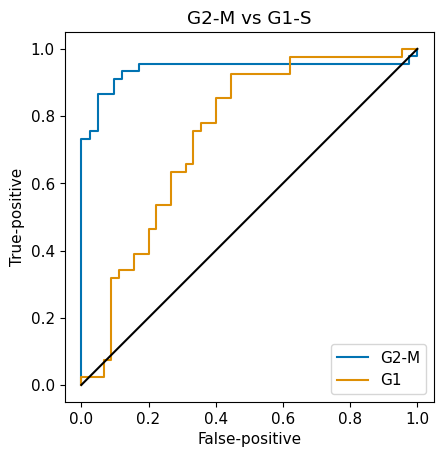

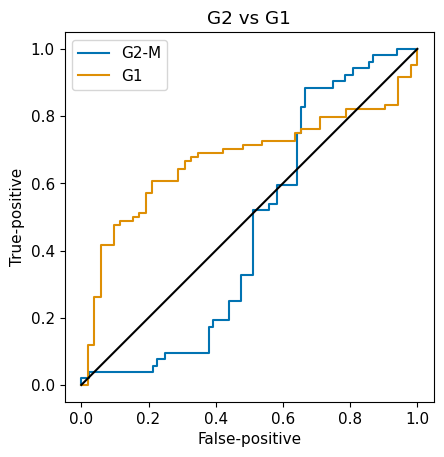

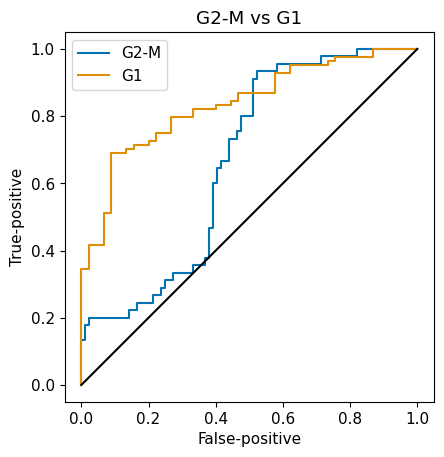

In [48]:
results_article = run_original_roc_code(
    adata,
    g1_list=g1_list,
    s_list=s_list,
    g2m_list=g2m_list,
    plot=True
)

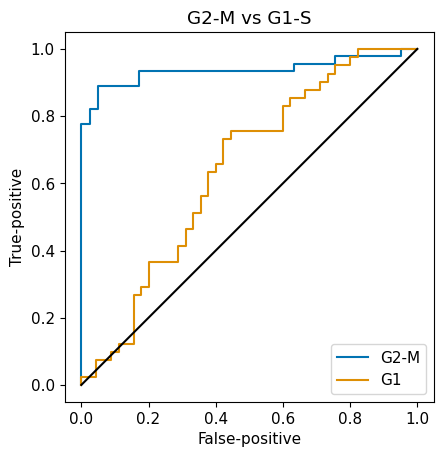

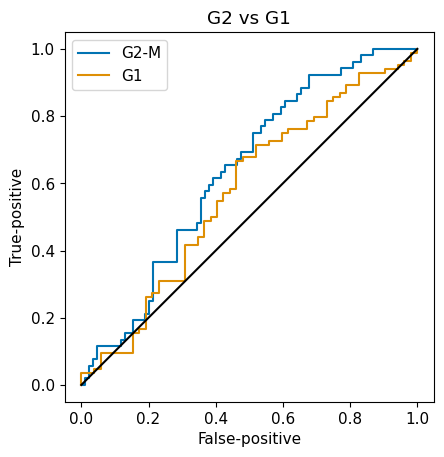

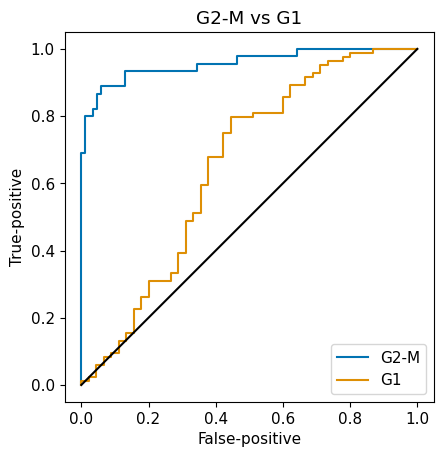

In [49]:
results_soft = run_original_roc_code(
    adata_soft,
    g1_list=g1_list,
    s_list=s_list,
    g2m_list=g2m_list,
    plot=True
)

In [50]:
df_soft_auc = pd.DataFrame([
    {
        "comparison": x["comparison"],
        "phase_score": x["phase_score"],
        "auc_soft": x["auc"]
    }
    for x in results_soft
])

df_article_auc = pd.DataFrame([
    {
        "comparison": x["comparison"],
        "phase_score": x["phase_score"],
        "auc_article": x["auc"]
    }
    for x in results_article
])

df_compare = df_article_auc.merge(df_soft_auc, on=["comparison", "phase_score"])
df_compare["delta_auc"] = df_compare["auc_soft"] - df_compare["auc_article"]
df_compare

,comparison,phase_score,auc_article,auc_soft,delta_auc
0,G2-M_vs_G1-S,G2-M,0.939295,0.936043,-0.003252
1,G2-M_vs_G1-S,G1,0.743631,0.640650,-0.102981
2,G2_vs_G1,G2-M,0.460394,0.632784,0.172390
3,G2_vs_G1,G1,0.671474,0.573718,-0.097756
4,G2-M_vs_G1,G2-M,0.664815,0.956349,0.291534
5,G2-M_vs_G1,G1,0.835714,0.652116,-0.183598


In [54]:
def export_roc_inputs(results, method_name, out_file):
    rows = []
    for x in results:
        for i, (yt, ys) in enumerate(zip(x["y_true"], x["y_score"])):
            rows.append({
                "method": method_name,
                "comparison": x["comparison"],
                "phase_score": x["phase_score"],
                "idx": i,
                "y_true": int(yt),
                "y_score": float(ys)
            })
    pd.DataFrame(rows).to_csv(out_file, sep="\t", index=False)

export_roc_inputs(results_article, "article", "roc_article_inputs.tsv")
export_roc_inputs(results_soft, "softhybrid", "roc_soft_inputs.tsv")

In [106]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve

def plot_g2m_vs_g1_four_roc(results_article, results_soft,
                           comparison_name="G2-M_vs_G1",
                           title="ROC curves: G2-M vs G1 (Brunner et al.)"):

    phase_order = ["G2-M", "S", "G1"]

    phase_colors = {
        "G2-M": "#1f77b4",
        "S": "#ff7f0e",
        "G1": "#2ca02c"
    }

    article_sub = [x for x in results_article if x["comparison"] == comparison_name]
    soft_sub = [x for x in results_soft if x["comparison"] == comparison_name]

    article_dict = {x["phase_score"]: x for x in article_sub}
    soft_dict = {x["phase_score"]: x for x in soft_sub}

    fig, ax = plt.subplots(figsize=(7,7))
    
    fig.patch.set_facecolor("white")
    ax.set_facecolor("white")

    for phase in phase_order:

        if phase in article_dict:
            x = article_dict[phase]
            fpr, tpr, _ = roc_curve(x["y_true"], x["y_score"])

            ax.plot(
                fpr, tpr,
                color=phase_colors[phase],
                linewidth=2.8,
                linestyle="-",
                label=f"{phase} Article (AUC=$\\mathbf{{{x['auc']:.3f}}}$)"
            )

        if phase in soft_dict:
            x = soft_dict[phase]
            fpr, tpr, _ = roc_curve(x["y_true"], x["y_score"])

            ax.plot(
                fpr, tpr,
                color=phase_colors[phase],
                linewidth=2.8,
                linestyle="--",
                label=f"{phase} SoftHybrid (AUC=$\\mathbf{{{x['auc']:.3f}}}$)"
            )

    # diagonal
    ax.plot([0,1],[0,1], linestyle=":", color="black", linewidth=2)

    # labels
    ax.set_title(title, fontsize=18, fontweight="bold")
    ax.set_xlabel("False Positive Rate", fontsize=16, fontweight="bold")
    ax.set_ylabel("True Positive Rate", fontsize=16, fontweight="bold")

    ax.set_xlim(0,1)
    ax.set_ylim(0,1)

    ax.tick_params(axis="both", labelsize=13)
    
    ax.grid(False)

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    ax.legend(fontsize=14, frameon=False)  

    ax.set_aspect("equal")

    fig.tight_layout()

    return fig, ax

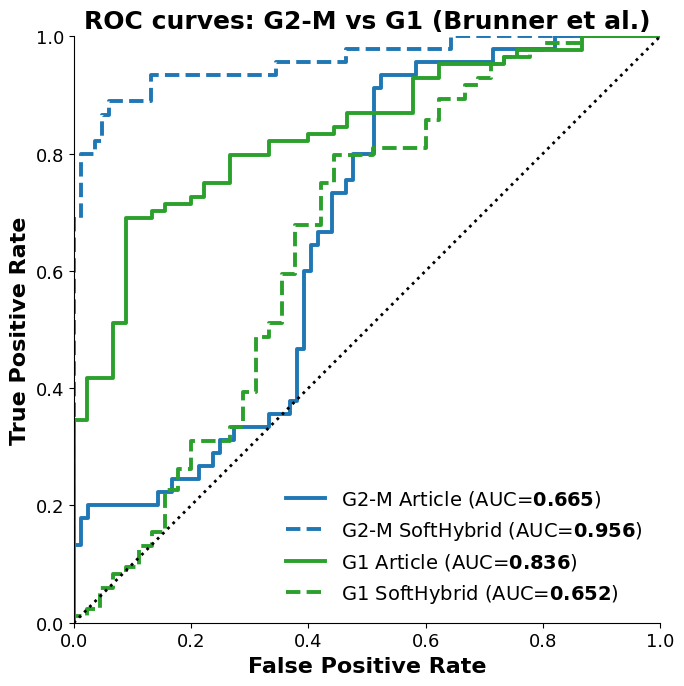

In [107]:
fig, ax = plot_g2m_vs_g1_four_roc(results_article, results_soft)

fig.savefig("G2M_vs_G1_ROC.pdf", dpi=300, bbox_inches="tight")
fig.savefig("G2M_vs_G1_ROC.png", dpi=600, bbox_inches="tight")

plt.show()

In [108]:
def plot_g2m_vs_g1s_four_roc(results_article, results_soft,
                           comparison_name="G2-M_vs_G1-S",
                           title="ROC curves: G2-M vs G1-S (Brunner et al.)"):

    phase_order = ["G2-M", "S", "G1"]

    phase_colors = {
        "G2-M": "#1f77b4",
        "S": "#ff7f0e",
        "G1": "#2ca02c"
    }

    article_sub = [x for x in results_article if x["comparison"] == comparison_name]
    soft_sub = [x for x in results_soft if x["comparison"] == comparison_name]

    article_dict = {x["phase_score"]: x for x in article_sub}
    soft_dict = {x["phase_score"]: x for x in soft_sub}

    fig, ax = plt.subplots(figsize=(7,7))
    
    fig.patch.set_facecolor("white")
    ax.set_facecolor("white")

    for phase in phase_order:

        if phase in article_dict:
            x = article_dict[phase]
            fpr, tpr, _ = roc_curve(x["y_true"], x["y_score"])

            ax.plot(
                fpr, tpr,
                color=phase_colors[phase],
                linewidth=2.8,
                linestyle="-",
                label=f"{phase} Article (AUC=$\\mathbf{{{x['auc']:.3f}}}$)"
            )

        if phase in soft_dict:
            x = soft_dict[phase]
            fpr, tpr, _ = roc_curve(x["y_true"], x["y_score"])

            ax.plot(
                fpr, tpr,
                color=phase_colors[phase],
                linewidth=2.8,
                linestyle="--",
                label=f"{phase} SoftHybrid (AUC=$\\mathbf{{{x['auc']:.3f}}}$)"
            )

    # diagonal
    ax.plot([0,1],[0,1], linestyle=":", color="black", linewidth=2)

    # labels
    ax.set_title(title, fontsize=18, fontweight="bold")
    ax.set_xlabel("False Positive Rate", fontsize=16, fontweight="bold")
    ax.set_ylabel("True Positive Rate", fontsize=16, fontweight="bold")

    ax.set_xlim(0,1)
    ax.set_ylim(0,1)

    ax.tick_params(axis="both", labelsize=13)
    
    ax.grid(False)

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    ax.legend(fontsize=14, frameon=False)  

    ax.set_aspect("equal")

    fig.tight_layout()

    return fig, ax

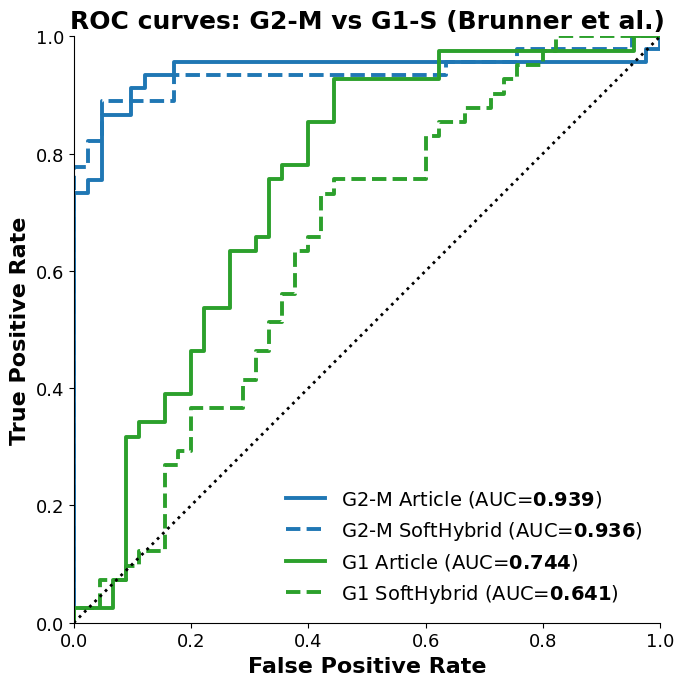

In [109]:
fig, ax = plot_g2m_vs_g1s_four_roc(results_article, results_soft)

fig.savefig("G2M_vs_G1S_ROC.pdf", dpi=300, bbox_inches="tight")
fig.savefig("G2M_vs_G1S_ROC.png", dpi=600, bbox_inches="tight")

plt.show()

In [110]:
def plot_g2_vs_g1_four_roc(results_article, results_soft,
                           comparison_name="G2_vs_G1",
                           title="ROC curves: G2 vs G1 (Brunner et al.)"):

    phase_order = ["G2-M", "S", "G1"]

    phase_colors = {
        "G2-M": "#1f77b4",
        "S": "#ff7f0e",
        "G1": "#2ca02c"
    }

    article_sub = [x for x in results_article if x["comparison"] == comparison_name]
    soft_sub = [x for x in results_soft if x["comparison"] == comparison_name]

    article_dict = {x["phase_score"]: x for x in article_sub}
    soft_dict = {x["phase_score"]: x for x in soft_sub}

    fig, ax = plt.subplots(figsize=(7,7))
    
    fig.patch.set_facecolor("white")
    ax.set_facecolor("white")

    for phase in phase_order:

        if phase in article_dict:
            x = article_dict[phase]
            fpr, tpr, _ = roc_curve(x["y_true"], x["y_score"])

            ax.plot(
                fpr, tpr,
                color=phase_colors[phase],
                linewidth=2.8,
                linestyle="-",
                label=f"{phase} Article (AUC=$\\mathbf{{{x['auc']:.3f}}}$)"
            )

        if phase in soft_dict:
            x = soft_dict[phase]
            fpr, tpr, _ = roc_curve(x["y_true"], x["y_score"])

            ax.plot(
                fpr, tpr,
                color=phase_colors[phase],
                linewidth=2.8,
                linestyle="--",
                label=f"{phase} SoftHybrid (AUC=$\\mathbf{{{x['auc']:.3f}}}$)"
            )

    # diagonal
    ax.plot([0,1],[0,1], linestyle=":", color="black", linewidth=2)

    # labels
    ax.set_title(title, fontsize=18, fontweight="bold")
    ax.set_xlabel("False Positive Rate", fontsize=16, fontweight="bold")
    ax.set_ylabel("True Positive Rate", fontsize=16, fontweight="bold")

    ax.set_xlim(0,1)
    ax.set_ylim(0,1)

    ax.tick_params(axis="both", labelsize=13)
    
    ax.grid(False)

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    ax.legend(fontsize=14, frameon=False)  

    ax.set_aspect("equal")

    fig.tight_layout()

    return fig, ax

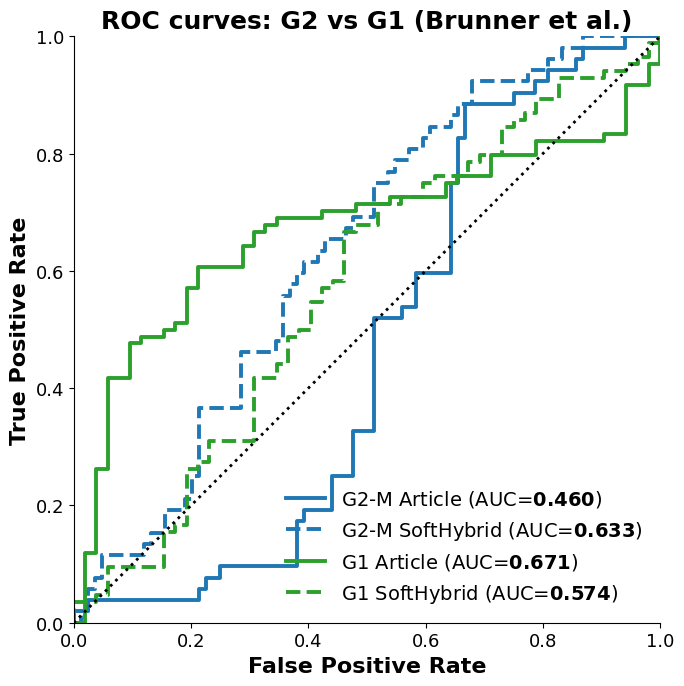

In [111]:
fig, ax = plot_g2_vs_g1_four_roc(results_article, results_soft)

fig.savefig("G2_vs_G1_ROC.pdf", dpi=300, bbox_inches="tight")
fig.savefig("G2_vs_G1_ROC.png", dpi=600, bbox_inches="tight")

plt.show()

# Benchmarking on Public Datasets with no imputation

No imputation AUC: 0.9254
SoftHybrid AUC: 0.9455
Delta AUC (SoftHybrid - No imputation): 0.0201
          method  comparison phase_score       auc  n_cells  n_markers  \
0  No_imputation  G2-M_vs_G1        G2-M  0.925397      129         12   
1     SoftHybrid  G2-M_vs_G1        G2-M  0.945503      129         12   

   delta_vs_noimputation  
0               0.000000  
1               0.020106  


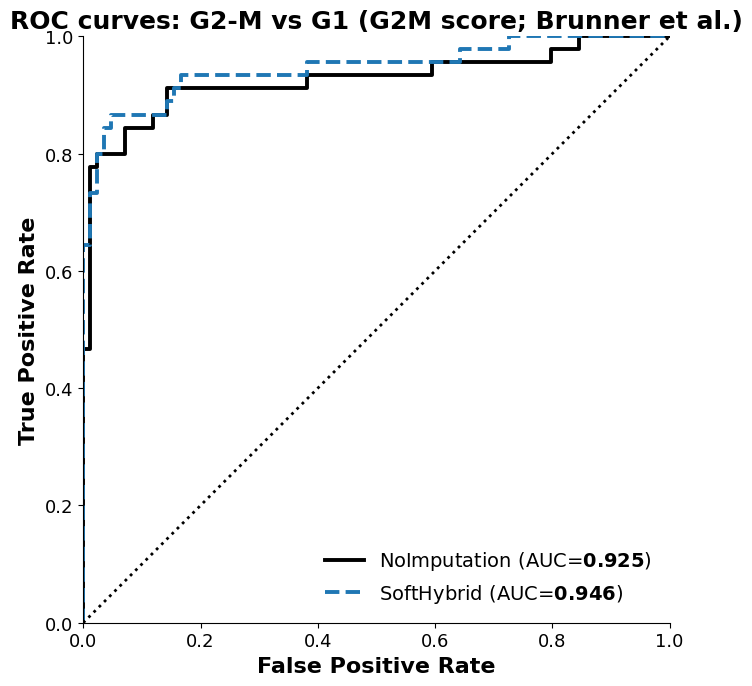

In [112]:
import os
import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

# =========================================================
# 0. output dir
# =========================================================
outdir = "./ROC_G2M_vs_G1_NoImputation_vs_SoftHybrid_scanpyScore"
os.makedirs(outdir, exist_ok=True)

# =========================================================
# 1. assign cell-cycle stage
# =========================================================
def assign_stage(adata):
    adata = adata.copy()

    adata.obs['cell cycle stage'] = [
        'G1' if '_G1_' in name
        else 'G1-S' if '_TB_' in name
        else 'G2' if '_G2_' in name
        else 'G2-M' if '_NB_' in name
        else 'other'
        for name in adata.obs_names
    ]

    adata = adata[adata.obs['cell cycle stage'] != 'other'].copy()
    return adata

# =========================================================
# 2. article-like preprocessing WITHOUT imputation
#    keep NA after log1p
# =========================================================
def prepare_noimputation_adata(protein_adata):
    adata = protein_adata.copy()

    sc.pp.filter_cells(adata, min_genes=600)
    sc.pp.filter_genes(adata, min_cells=int(np.ceil(0.7 * adata.shape[0])))
    sc.pp.log1p(adata)

    # IMPORTANT:
    # do not replace NA with 0
    adata = assign_stage(adata)

    return adata

# =========================================================
# 3. load SoftHybrid matrix into filtered reference
# =========================================================
def load_softhybrid_adata(adata_reference, soft_file):
    df_soft = pd.read_csv(soft_file, sep="\t", index_col=0)

    adata_soft = adata_reference.copy()

    # rows = proteins, cols = samples
    common_cells = [c for c in adata_soft.obs_names if c in df_soft.columns]
    common_genes = [g for g in adata_soft.var_names if g in df_soft.index]

    adata_soft = adata_soft[common_cells, common_genes].copy()
    df_soft = df_soft.loc[common_genes, common_cells]

    assert list(df_soft.index) == list(adata_soft.var_names)
    assert list(df_soft.columns) == list(adata_soft.obs_names)

    adata_soft.X = df_soft.T.values
    adata_soft = assign_stage(adata_soft)

    return adata_soft

# =========================================================
# 4. ROC using standard scanpy score_genes()
# =========================================================
def run_g2m_vs_g1_roc_scanpy_score(adata, g2m_list, method_name="method"):
    adata = adata.copy()

    # only keep G2-M and G1
    adata = adata[
        np.array(adata.obs['cell cycle stage'] == 'G2-M') |
        np.array(adata.obs['cell cycle stage'] == 'G1')
    ].copy()

    # keep only markers present
    g2m_use = [g for g in g2m_list if g in adata.var_names]
    if len(g2m_use) == 0:
        raise ValueError(f"[{method_name}] No G2M markers found in adata.var_names.")

    # original/article-style scoring method
    sc.tl.score_genes(
        adata,
        gene_list=g2m_use,
        score_name='g2m',
        use_raw=False
    )

    # remove cells with NA score
    valid = ~pd.isna(adata.obs['g2m'].values)
    adata = adata[valid].copy()

    y_true = (adata.obs['cell cycle stage'] == 'G2-M').astype(int).values
    y_score = adata.obs['g2m'].values.astype(float)

    auc_val = roc_auc_score(y_true, y_score)
    fpr, tpr, thresholds = roc_curve(y_true, y_score)

    res = {
        "method": method_name,
        "comparison": "G2-M_vs_G1",
        "phase_score": "G2-M",
        "auc": auc_val,
        "fpr": fpr,
        "tpr": tpr,
        "thresholds": thresholds,
        "y_true": y_true,
        "y_score": y_score,
        "cell_id": adata.obs_names.tolist(),
        "stage": adata.obs['cell cycle stage'].tolist(),
        "n_cells": adata.n_obs,
        "n_markers": len(g2m_use)
    }

    return res

# =========================================================
# 5. export ROC inputs for DeLong in R
# =========================================================
def export_roc_inputs(results_list, out_file):
    rows = []

    for res in results_list:
        for i, (cid, st, yt, ys) in enumerate(zip(
            res["cell_id"], res["stage"], res["y_true"], res["y_score"]
        )):
            rows.append({
                "method": res["method"],
                "comparison": res["comparison"],
                "phase_score": res["phase_score"],
                "idx": i,
                "cell_id": cid,
                "stage": st,
                "y_true": int(yt),
                "y_score": float(ys)
            })

    df_out = pd.DataFrame(rows)
    df_out.to_csv(out_file, sep="\t", index=False)
    return df_out

# =========================================================
# 6. plot ROC
# =========================================================
def plot_noimp_vs_soft_roc(res_noimp, res_soft,
                           title="ROC curves: G2-M vs G1 (G2M score; Brunner et al.)"):

    fig, ax = plt.subplots(figsize=(7, 7))

    fig.patch.set_facecolor("white")
    ax.set_facecolor("white")

    ax.plot(
        res_noimp["fpr"], res_noimp["tpr"],
        color="#000000",
        linewidth=2.8,
        linestyle="-",
        label=f"NoImputation (AUC=$\\mathbf{{{res_noimp['auc']:.3f}}}$)"
    )

    ax.plot(
        res_soft["fpr"], res_soft["tpr"],
        color="#1f77b4",
        linewidth=2.8,
        linestyle="--",
        label=f"SoftHybrid (AUC=$\\mathbf{{{res_soft['auc']:.3f}}}$)"
    )

    ax.plot([0, 1], [0, 1], linestyle=":", color="black", linewidth=2)

    ax.set_title(title, fontsize=18, fontweight="bold")
    ax.set_xlabel("False Positive Rate", fontsize=16, fontweight="bold")
    ax.set_ylabel("True Positive Rate", fontsize=16, fontweight="bold")

    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)

    ax.tick_params(axis="both", labelsize=13)

    ax.grid(False)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.legend(
        fontsize=14,
        frameon=False,
        loc="lower right"
    )

    ax.set_aspect("equal")
    fig.tight_layout()

    return fig, ax

# =========================================================
# 7. run
# =========================================================

# 7.1 no-imputation data
adata_noimp = prepare_noimputation_adata(protein_adata)

# 7.2 SoftHybrid data
# use same filtered reference for fair comparison
adata_soft = load_softhybrid_adata(
    adata_reference=adata_noimp,
    soft_file="SoftHybridImputation_best_both.tsv"
)

# 7.3 ROC with standard scanpy score
res_noimp = run_g2m_vs_g1_roc_scanpy_score(
    adata=adata_noimp,
    g2m_list=g2m_list,
    method_name="No_imputation"
)

res_soft = run_g2m_vs_g1_roc_scanpy_score(
    adata=adata_soft,
    g2m_list=g2m_list,
    method_name="SoftHybrid"
)

print("No imputation AUC:", round(res_noimp["auc"], 4))
print("SoftHybrid AUC:", round(res_soft["auc"], 4))
print("Delta AUC (SoftHybrid - No imputation):", round(res_soft["auc"] - res_noimp["auc"], 4))

# =========================================================
# 8. export ROC inputs
# =========================================================
df_roc_inputs = export_roc_inputs(
    [res_noimp, res_soft],
    os.path.join(outdir, "roc_inputs_noimputation_vs_softhybrid_G2M_vs_G1_scanpyScore.tsv")
)

# export AUC summary
df_auc = pd.DataFrame([
    {
        "method": res_noimp["method"],
        "comparison": res_noimp["comparison"],
        "phase_score": res_noimp["phase_score"],
        "auc": res_noimp["auc"],
        "n_cells": res_noimp["n_cells"],
        "n_markers": res_noimp["n_markers"]
    },
    {
        "method": res_soft["method"],
        "comparison": res_soft["comparison"],
        "phase_score": res_soft["phase_score"],
        "auc": res_soft["auc"],
        "n_cells": res_soft["n_cells"],
        "n_markers": res_soft["n_markers"]
    }
])

df_auc["delta_vs_noimputation"] = df_auc["auc"] - df_auc.loc[
    df_auc["method"] == "No_imputation", "auc"
].values[0]

df_auc.to_csv(
    os.path.join(outdir, "auc_summary_noimputation_vs_softhybrid_G2M_vs_G1_scanpyScore.tsv"),
    sep="\t",
    index=False
)

print(df_auc)

# =========================================================
# 9. plot and save
# =========================================================
fig, ax = plot_noimp_vs_soft_roc(res_noimp, res_soft)

fig.savefig(
    os.path.join(outdir, "G2M_vs_G1_ROC_noimputation_vs_softhybrid_scanpyScore.pdf"),
    dpi=300,
    bbox_inches="tight"
)

fig.savefig(
    os.path.join(outdir, "G2M_vs_G1_ROC_noimputation_vs_softhybrid_scanpyScore.png"),
    dpi=600,
    bbox_inches="tight"
)

plt.show()